# ECON4002 — Week 4: Optimization in R

**University of Western Australia**  
*R implementations for unconstrained and constrained optimization, Hessians, and bordered Hessians*

---

## Key Formulae

First-order condition: $\frac{d\pi}{dq} = 0$. Lagrangian: $\mathcal{L} = f(x,y) - \lambda(g(x,y) - c)$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 4 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 4: Optimization in R — ready!\n')

Week 4: Optimization in R — ready!


## Single Variable

### W4-CS01 — Single Variable Optimization with optimize()

> **Note:** optimize() is for single-variable problems. Use maximum=TRUE for maximization.

**Common errors:**
- Forgetting maximum=TRUE (default is minimization)
- Interval too narrow missing the optimum

In [ ]:
# Profit function: π(Q) = 100Q - 3Q²
profit <- function(Q) 100 * Q - 3 * Q^2

# Find maximum (optimize uses interval search)
result <- optimize(profit, interval = c(0, 50), maximum = TRUE)

cat("Q* =", result$maximum, "\n")
cat("π* =", result$objective, "\n")

# Verify with calculus: dπ/dQ = 100 - 6Q = 0 → Q* = 16.67

### W4-CS02 — FOC and SOC Verification

> **Note:** Numerical derivatives verify analytical work. SOC < 0 confirms maximum.

In [ ]:
# Numerical derivatives for verification
profit <- function(Q) 100 * Q - 3 * Q^2

# First derivative (marginal)
marginal <- function(Q, h = 1e-6) {
  (profit(Q + h) - profit(Q - h)) / (2 * h)
}

# Second derivative
second_deriv <- function(Q, h = 1e-5) {
  (profit(Q + h) - 2*profit(Q) + profit(Q - h)) / h^2
}

Q_star <- 100/6  # Analytical solution

cat("At Q* =", round(Q_star, 2), ":\n")
cat("FOC: dπ/dQ =", round(marginal(Q_star), 6), "(should be ≈ 0)\n")
cat("SOC: d²π/dQ² =", round(second_deriv(Q_star), 2), "(should be < 0 for max)\n")

## Multivariate

### W4-CS03 — Multi-Variable Optimization with optim()

> **Note:** optim() minimizes by default. For maximization, minimize the negative.

**Common errors:**
- Using wrong sign (minimizing instead of maximizing)
- Poor starting values causing convergence to local optimum

In [ ]:
# Profit: π(L,K) = 50L^0.3 K^0.5 - 2L - 3K
# optim() minimizes, so we minimize negative profit

neg_profit <- function(x) {
  L <- x[1]
  K <- x[2]
  -(50 * L^0.3 * K^0.5 - 2*L - 3*K)
}

# Starting point matters for convergence
result <- optim(
  par = c(10, 10),      # Initial guess
  fn = neg_profit,
  method = "BFGS",       # Quasi-Newton method
  control = list(maxit = 1000)
)

L_star <- result$par[1]
K_star <- result$par[2]
profit_star <- -result$value

cat("Optimal inputs: L* =", round(L_star, 2), ", K* =", round(K_star, 2), "\n")
cat("Maximum profit: π* =", round(profit_star, 2))

### W4-CS04 — Computing the Gradient Numerically

> **Note:** Gradient = 0 is the FOC for multivariate optimization.

In [ ]:
# Numerical gradient (vector of partial derivatives)
gradient <- function(f, x, h = 1e-6) {
  n <- length(x)
  grad <- numeric(n)
  for (i in 1:n) {
    x_plus <- x_minus <- x
    x_plus[i] <- x[i] + h
    x_minus[i] <- x[i] - h
    grad[i] <- (f(x_plus) - f(x_minus)) / (2 * h)
  }
  return(grad)
}

# Example: f(x,y) = x² + 2xy + 3y²
f <- function(x) x[1]^2 + 2*x[1]*x[2] + 3*x[2]^2

# Gradient at (1, 1)
grad <- gradient(f, c(1, 1))
cat("∇f(1,1) =", grad, "\n")
cat("Analytical: (2x + 2y, 2x + 6y) = (4, 8)")

## Hessian

### W4-CS05 — Computing the Hessian Matrix

In [ ]:
# Numerical Hessian (matrix of second derivatives)
hessian <- function(f, x, h = 1e-5) {
  n <- length(x)
  H <- matrix(0, n, n)
  for (i in 1:n) {
    for (j in 1:n) {
      x_pp <- x_pm <- x_mp <- x_mm <- x
      x_pp[i] <- x_pp[i] + h; x_pp[j] <- x_pp[j] + h
      x_pm[i] <- x_pm[i] + h; x_pm[j] <- x_pm[j] - h
      x_mp[i] <- x_mp[i] - h; x_mp[j] <- x_mp[j] + h
      x_mm[i] <- x_mm[i] - h; x_mm[j] <- x_mm[j] - h
      H[i, j] <- (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * h^2)
    }
  }
  return(H)
}

# Example
f <- function(x) -2*x[1]^2 - 3*x[2]^2 + 4*x[1]*x[2]
H <- hessian(f, c(1, 1))
cat("Hessian:\n")
print(round(H, 2))

### W4-CS06 — Checking Definiteness

> **Note:** For 2×2: Neg def if H₁₁ < 0 and det(H) > 0. Pos def if H₁₁ > 0 and det(H) > 0.

In [ ]:
# Check definiteness using eigenvalues
check_definiteness <- function(H) {
  eig <- eigen(H)$values
  cat("Eigenvalues:", round(eig, 4), "\n")
  
  if (all(eig > 0)) {
    return("Positive definite → MINIMUM")
  } else if (all(eig < 0)) {
    return("Negative definite → MAXIMUM")
  } else if (all(eig >= 0)) {
    return("Positive semi-definite")
  } else if (all(eig <= 0)) {
    return("Negative semi-definite")
  } else {
    return("Indefinite → SADDLE POINT")
  }
}

# Alternative: Check leading principal minors
check_minors <- function(H) {
  n <- nrow(H)
  minors <- numeric(n)
  for (k in 1:n) {
    minors[k] <- det(H[1:k, 1:k])
  }
  cat("Leading principal minors:", round(minors, 4), "\n")
  
  # Positive definite: all minors > 0
  # Negative definite: alternating signs starting with -
  return(minors)
}

# Test
H <- matrix(c(-4, 4, 4, -6), nrow = 2)
cat(check_definiteness(H), "\n")
check_minors(H)

## Constrained

### W4-CS07 — Constrained Optimization with nloptr

> **Note:** nloptr handles equality and inequality constraints. COBYLA is derivative-free.

In [ ]:
library(nloptr)

# Minimize cost C = 3L + 4K
# Subject to: 2L^0.5 K^0.5 = 160

cost <- function(x) {
  L <- x[1]; K <- x[2]
  return(3*L + 4*K)
}

# Equality constraint (must equal zero)
production_constraint <- function(x) {
  L <- x[1]; K <- x[2]
  return(2 * L^0.5 * K^0.5 - 160)
}

result <- nloptr(
  x0 = c(50, 50),          # Starting point
  eval_f = cost,           # Objective function
  eval_g_eq = production_constraint,  # Equality constraint
  lb = c(0, 0),            # Lower bounds (non-negativity)
  opts = list(
    algorithm = "NLOPT_LN_COBYLA",
    xtol_rel = 1e-8,
    maxeval = 1000
  )
)

cat("L* =", round(result$solution[1], 2), "\n")
cat("K* =", round(result$solution[2], 2), "\n")
cat("Min cost =", round(result$objective, 2))

### W4-CS08 — Utility Maximization Example

> **Note:** Cobb-Douglas demands: x* = αm/p₁, y* = (1-α)m/p₂

In [ ]:
library(nloptr)

# Maximize u = x^0.4 y^0.6 subject to 2x + 3y = 120

# We minimize negative utility
neg_utility <- function(x) {
  -(x[1]^0.4 * x[2]^0.6)
}

budget_constraint <- function(x) {
  2*x[1] + 3*x[2] - 120
}

result <- nloptr(
  x0 = c(20, 20),
  eval_f = neg_utility,
  eval_g_eq = budget_constraint,
  lb = c(0.001, 0.001),  # Avoid zero (log issues)
  opts = list(algorithm = "NLOPT_LN_COBYLA", xtol_rel = 1e-8)
)

x_star <- result$solution
cat("Optimal bundle: x* =", round(x_star[1], 2), 
    ", y* =", round(x_star[2], 2), "\n")
cat("Max utility:", round(-result$objective, 4), "\n")

# Verify with Cobb-Douglas formula
alpha <- 0.4; m <- 120; p1 <- 2; p2 <- 3
cat("\nAnalytical (Cobb-Douglas):\n")
cat("x* = αm/p₁ =", alpha * m / p1, "\n")
cat("y* = (1-α)m/p₂ =", (1-alpha) * m / p2)

## Bordered Hessian

### W4-CS09 — Constructing the Bordered Hessian

> **Note:** Bordered Hessian includes constraint info. Sign condition differs from regular Hessian.

In [ ]:
# Bordered Hessian for constrained optimization
# Structure: [0, g_x, g_y; g_x, L_xx, L_xy; g_y, L_xy, L_yy]

bordered_hessian <- function(g_grad, L_hess) {
  # g_grad: gradient of constraint [g_x, g_y]
  # L_hess: Hessian of Lagrangian (2x2)
  
  n <- length(g_grad)
  H_bar <- matrix(0, n + 1, n + 1)
  
  # First row/column: constraint gradient
  H_bar[1, 1] <- 0
  H_bar[1, 2:(n+1)] <- g_grad
  H_bar[2:(n+1), 1] <- g_grad
  
  # Lower-right: Lagrangian Hessian
  H_bar[2:(n+1), 2:(n+1)] <- L_hess
  
  return(H_bar)
}

# Example: max u = x^0.5 y^0.5 s.t. 2x + y = 60
# At optimum (x*, y*) = (15, 30)

# Constraint gradient
g_grad <- c(2, 1)  # g = 2x + y

# Lagrangian second derivatives (need λ* first)
# From FOC: λ* = 0.5 * x^(-0.5) * y^0.5 / 2 = 0.177
lambda <- 0.177
x_star <- 15; y_star <- 30

L_xx <- -0.25 * x_star^(-1.5) * y_star^0.5
L_yy <- -0.25 * x_star^0.5 * y_star^(-1.5)
L_xy <- 0.25 * x_star^(-0.5) * y_star^(-0.5)

L_hess <- matrix(c(L_xx, L_xy, L_xy, L_yy), nrow = 2)

H_bar <- bordered_hessian(g_grad, L_hess)
cat("Bordered Hessian:\n")
print(round(H_bar, 4))
cat("\nDeterminant:", round(det(H_bar), 4))
cat("\nFor MAX with 1 constraint, 2 vars: need det > 0")

### W4-CS10 — Complete Bordered Hessian Check

> **Note:** This function automates the bordered Hessian construction and SOC check.

In [ ]:
# Full function to verify constrained SOC
check_constrained_SOC <- function(f, g, x_star, lambda_star, type = "max") {
  h <- 1e-5
  n <- length(x_star)
  
  # Compute gradient of constraint
  g_grad <- numeric(n)
  for (i in 1:n) {
    x_plus <- x_minus <- x_star
    x_plus[i] <- x_plus[i] + h
    x_minus[i] <- x_minus[i] - h
    g_grad[i] <- (g(x_plus) - g(x_minus)) / (2 * h)
  }
  
  # Lagrangian: L = f + λ(c - g)
  # For our convention, Hessian of L = Hessian of f - λ * Hessian of g
  # But if g is linear, Hessian of g = 0, so H_L = H_f
  
  # Compute Hessian of Lagrangian numerically
  L <- function(x) f(x) - lambda_star * g(x)
  
  H_L <- matrix(0, n, n)
  for (i in 1:n) {
    for (j in 1:n) {
      x_pp <- x_pm <- x_mp <- x_mm <- x_star
      x_pp[i] <- x_pp[i] + h; x_pp[j] <- x_pp[j] + h
      x_pm[i] <- x_pm[i] + h; x_pm[j] <- x_pm[j] - h
      x_mp[i] <- x_mp[i] - h; x_mp[j] <- x_mp[j] + h
      x_mm[i] <- x_mm[i] - h; x_mm[j] <- x_mm[j] - h
      H_L[i, j] <- (L(x_pp) - L(x_pm) - L(x_mp) + L(x_mm)) / (4 * h^2)
    }
  }
  
  # Construct bordered Hessian
  H_bar <- matrix(0, n + 1, n + 1)
  H_bar[1, 1] <- 0
  H_bar[1, 2:(n+1)] <- g_grad
  H_bar[2:(n+1), 1] <- g_grad
  H_bar[2:(n+1), 2:(n+1)] <- H_L
  
  det_H_bar <- det(H_bar)
  
  cat("Constraint gradient:", round(g_grad, 4), "\n")
  cat("Lagrangian Hessian:\n")
  print(round(H_L, 6))
  cat("\nBordered Hessian:\n")
  print(round(H_bar, 6))
  cat("\nDeterminant:", round(det_H_bar, 6), "\n")
  
  # Check condition (1 constraint, 2 variables)
  if (type == "max" && det_H_bar > 0) {
    cat("✓ SOC satisfied for MAXIMUM\n")
  } else if (type == "min" && det_H_bar < 0) {
    cat("✓ SOC satisfied for MINIMUM\n")
  } else {
    cat("✗ SOC NOT satisfied\n")
  }
  
  return(list(H_bar = H_bar, det = det_H_bar))
}

# Example usage
f <- function(x) x[1]^0.5 * x[2]^0.5  # Utility
g <- function(x) 2*x[1] + x[2] - 60   # Budget constraint = 0

result <- check_constrained_SOC(f, g, c(15, 30), lambda_star = 0.177, type = "max")

## Linear Programming

### W4-CS11 — Linear Programming with lpSolve

> **Note:** lpSolve handles linear optimization. Shadow prices from lp(..., compute.sens=TRUE).

In [ ]:
library(lpSolve)

# Maximize: 50x + 80y
# Subject to: x + y ≤ 100 (land)
#             2x + 3y ≤ 240 (water)
#             x, y ≥ 0

f.obj <- c(50, 80)  # Objective coefficients

f.con <- matrix(c(
  1, 1,    # Land constraint
  2, 3     # Water constraint
), nrow = 2, byrow = TRUE)

f.dir <- c("<=", "<=")
f.rhs <- c(100, 240)

result <- lp("max", f.obj, f.con, f.dir, f.rhs)

cat("Optimal allocation:\n")
cat("  x (crop 1) =", result$solution[1], "\n")
cat("  y (crop 2) =", result$solution[2], "\n")
cat("Maximum profit: $", result$objval, "\n")

# Check which constraints are binding
land_used <- sum(f.con[1,] * result$solution)
water_used <- sum(f.con[2,] * result$solution)
cat("\nResource usage:\n")
cat("  Land:", land_used, "/", f.rhs[1], 
    ifelse(abs(land_used - f.rhs[1]) < 0.01, "(BINDING)", "(slack)"), "\n")
cat("  Water:", water_used, "/", f.rhs[2],
    ifelse(abs(water_used - f.rhs[2]) < 0.01, "(BINDING)", "(slack)"), "\n")

### W4-CS12 — Shadow Prices in LP

> **Note:** Shadow price = marginal value of relaxing constraint by 1 unit.

In [ ]:
library(lpSolve)

# Same problem with sensitivity analysis
f.obj <- c(50, 80)
f.con <- matrix(c(1, 1, 2, 3), nrow = 2, byrow = TRUE)
f.dir <- c("<=", "<=")
f.rhs <- c(100, 240)

# Get shadow prices
result <- lp("max", f.obj, f.con, f.dir, f.rhs, compute.sens = TRUE)

cat("Optimal solution: x =", result$solution, "\n")
cat("Objective value:", result$objval, "\n\n")

# Shadow prices (dual values)
cat("Shadow prices interpretation:\n")
cat("  Land:", result$duals[1], 
    "(marginal value of extra hectare)\n")
cat("  Water:", round(result$duals[2], 2),
    "(marginal value of extra water unit)\n")

# Verify by perturbing RHS
rhs_perturbed <- c(101, 240)  # Add 1 hectare of land
result_new <- lp("max", f.obj, f.con, f.dir, rhs_perturbed)
cat("\nVerification (add 1 hectare):\n")
cat("  New profit:", result_new$objval, "\n")
cat("  Increase:", result_new$objval - result$objval, 
    "(should ≈ shadow price of land)\n")

## Visualization

### W4-CS13 — Plotting Optimization Landscape

> **Note:** Visualization helps understand constrained optimization geometry.

In [ ]:
# Visualize 2D optimization problem
# f(x,y) = -(x-3)² - (y-2)² (maximum at (3,2))

f <- function(x, y) -(x - 3)^2 - (y - 2)^2

# Create grid
x_seq <- seq(0, 6, length = 50)
y_seq <- seq(0, 4, length = 50)
z <- outer(x_seq, y_seq, f)

# Contour plot
contour(x_seq, y_seq, z, nlevels = 15,
        xlab = "x", ylab = "y",
        main = "Contour Plot of f(x,y)")

# Mark optimum
points(3, 2, pch = 19, col = "red", cex = 1.5)
text(3, 2.3, "Maximum", col = "red")

# Add constraint line: x + y = 4
abline(a = 4, b = -1, col = "blue", lwd = 2, lty = 2)
text(0.5, 3.5, "Constraint: x + y = 4", col = "blue")

# Constrained optimum (approximately)
points(2.33, 1.67, pch = 17, col = "green", cex = 1.5)
text(2.33, 1.3, "Constrained\noptimum", col = "green", cex = 0.8)

## Applications

### W4-CS14 — Agricultural Cost Minimization

> **Note:** This function solves a general 3-input cost minimization problem.

In [ ]:
# Farm cost minimization
# Minimize C = wL + rK + pF (labor, capital, fertilizer)
# Subject to Q = A * L^a * K^b * F^c = Q_target

farm_cost_min <- function(w, r, pF, A, a, b, c, Q_target) {
  library(nloptr)
  
  # Cost function
  cost <- function(x) {
    L <- x[1]; K <- x[2]; F <- x[3]
    w * L + r * K + pF * F
  }
  
  # Production constraint
  production <- function(x) {
    L <- x[1]; K <- x[2]; F <- x[3]
    A * L^a * K^b * F^c - Q_target
  }
  
  result <- nloptr(
    x0 = c(10, 10, 10),
    eval_f = cost,
    eval_g_eq = production,
    lb = c(0.01, 0.01, 0.01),
    opts = list(algorithm = "NLOPT_LN_COBYLA", xtol_rel = 1e-8)
  )
  
  L_star <- result$solution[1]
  K_star <- result$solution[2]
  F_star <- result$solution[3]
  C_star <- result$objective
  
  cat("=== Farm Cost Minimization ===", "\n")
  cat("Target output:", Q_target, "\n")
  cat("Optimal inputs:\n")
  cat("  Labor:", round(L_star, 2), "units\n")
  cat("  Capital:", round(K_star, 2), "units\n")
  cat("  Fertilizer:", round(F_star, 2), "units\n")
  cat("Minimum cost: $", round(C_star, 2), "\n")
  
  # Marginal cost (shadow price approximation)
  result2 <- nloptr(
    x0 = c(10, 10, 10),
    eval_f = cost,
    eval_g_eq = function(x) A * x[1]^a * x[2]^b * x[3]^c - (Q_target + 1),
    lb = c(0.01, 0.01, 0.01),
    opts = list(algorithm = "NLOPT_LN_COBYLA", xtol_rel = 1e-8)
  )
  
  MC <- result2$objective - C_star
  cat("Marginal cost (λ*):", round(MC, 2), "\n")
  
  return(list(L = L_star, K = K_star, F = F_star, C = C_star, MC = MC))
}

# Example
farm_cost_min(w = 15, r = 20, pF = 5, A = 2, a = 0.3, b = 0.4, c = 0.3, Q_target = 100)

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

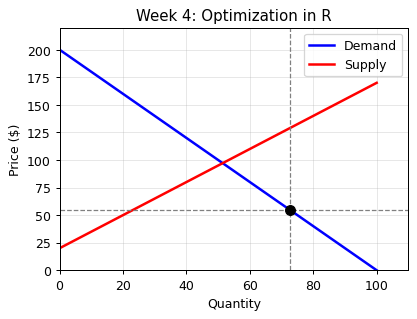

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Single Variable Max**

```r
result <- optimize(f, interval = c(low, high), maximum = TRUE)
x_star <- result$maximum
```

**Multi-Variable with optim()**

```r
# Minimize negative for maximization
result <- optim(par = c(x0), fn = function(x) -f(x), method = 'BFGS')
x_star <- result$par
```

**Constrained with nloptr**

```r
result <- nloptr(x0 = c(...), eval_f = objective, eval_g_eq = constraint,
                 opts = list(algorithm = 'NLOPT_LN_COBYLA'))
```

**Check SOC**

```r
H <- hessian(f, x_star)
eig <- eigen(H)$values
if (all(eig < 0)) 'Maximum' else if (all(eig > 0)) 'Minimum' else 'Saddle'
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `function cannot be evaluated at initial parameters` | Starting point is outside domain (e.g., negative input to log) | Use bounds (lb parameter) or better starting point |
| `convergence to wrong point` | Local vs global optimum, or poor starting point | Try multiple starting points; check if function is globally concave/convex |
| `NaN or Inf in Hessian` | Evaluating at boundary where derivatives undefined | Add small epsilon to avoid exact zeros; use interior point |
| `lpSolve returns 0 for solution` | Infeasible problem or unbounded | Check if constraints are compatible; verify problem setup |